In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

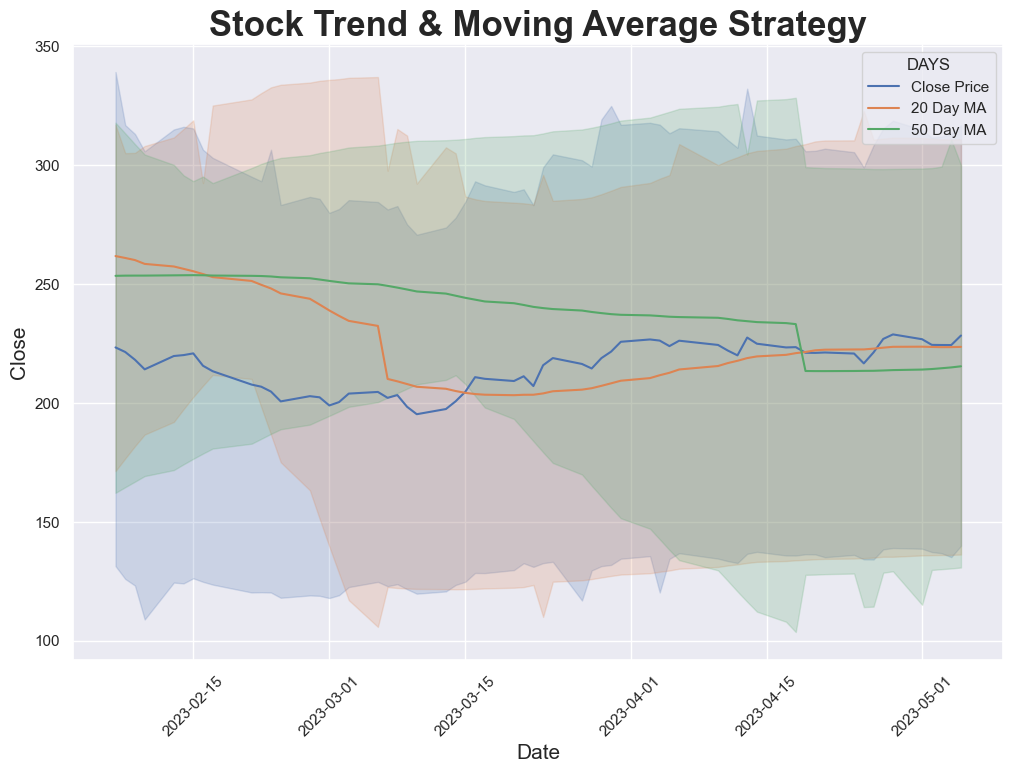

In [4]:
df = pd.read_csv("stocks.csv")

#Convert date and time
df["Date"] = pd.to_datetime(df["Date"])

#Moving Average
df["MA_20"] = df["Close"].rolling(window=20).mean()
df["MA_50"] = df["Close"].rolling(window=50).mean()

#Create Lineplot
plt.figure(figsize = (12,8))
sns.set(style = "darkgrid")

sns.lineplot(data = df,x = "Date", y = "Close", label = "Close Price")
sns.lineplot(data = df,x = "Date", y = "MA_20", label = "20 Day MA")
sns.lineplot(data = df,x = "Date", y = "MA_50", label = "50 Day MA")

plt.title("Stock Trend & Moving Average Strategy", fontsize = 25, fontweight = "bold")
plt.xlabel("Date", fontsize = 15)
plt.ylabel("Close", fontsize = 15)
plt.legend(title = "DAYS",loc = "upper right")
plt.xticks(rotation = 45)
plt.show()

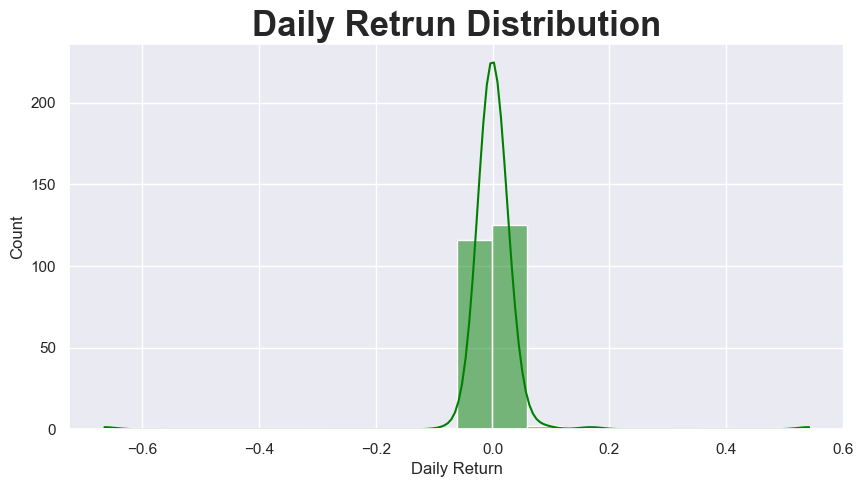

In [5]:
df["Daily Return"] = round(df["Close"].pct_change(),3)

plt.figure(figsize = (10,5))
sns.set(style = "darkgrid" )

sns.histplot(df["Daily Return"], bins = 20,kde = True, color = "green")
plt.title("Daily Retrun Distribution", fontsize = 25, fontweight = "bold")

plt.show()

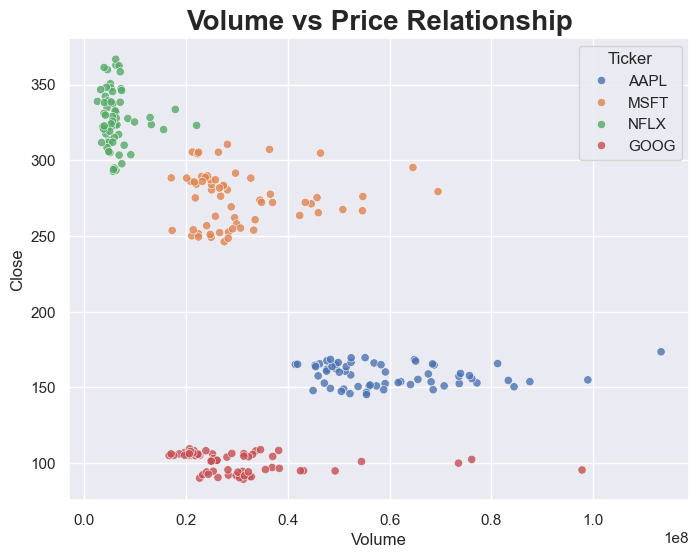

In [6]:
plt.figure(figsize = (8,6))

sns.scatterplot(data = df, x = "Volume", y = "Close", alpha = 0.8, color = "g", hue = "Ticker")
plt.title("Volume vs Price Relationship", fontsize = 20, fontweight = "bold")

plt.show()

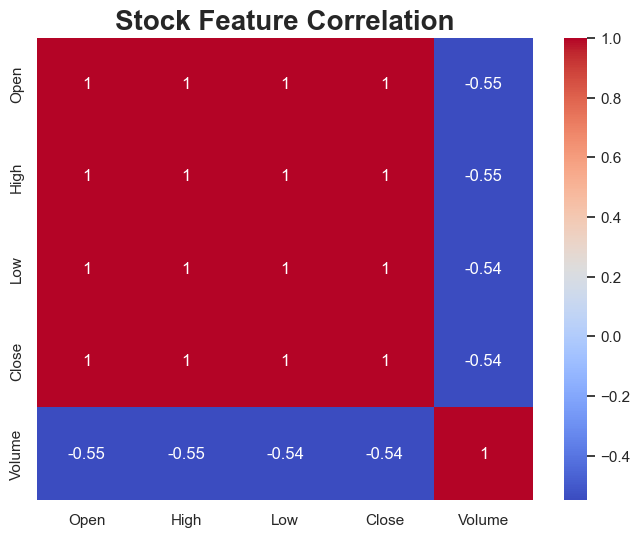

In [7]:
Corr = df[["Open", "High", "Low", "Close", "Volume"]].corr()
plt.figure(figsize = (8,6))

sns.heatmap(Corr, annot= True, cmap = "coolwarm")
plt.title("Stock Feature Correlation", fontsize = 20, fontweight = "bold")

plt.show()

In [8]:
Q1 = np.percentile(df["Close"], 25)
Q3 = np.percentile(df["Close"], 75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

Outlier = df[
    (df["Close"] < lower)|
    (df["Close"] > upper)  
]

print("Number Of Outlier:", len(Outlier))

Number Of Outlier: 0


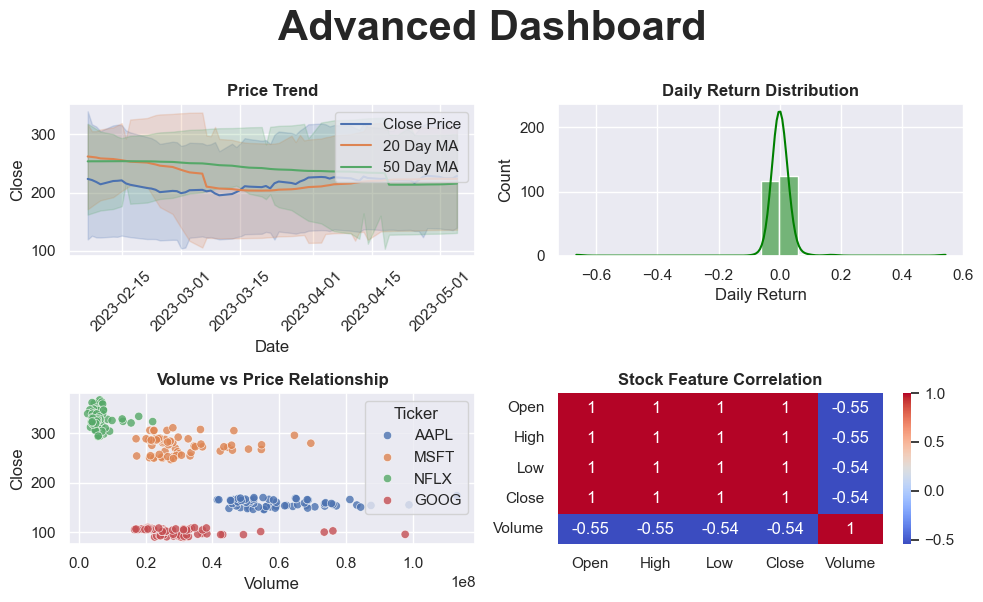

In [10]:
fig, axes = plt.subplots(2,2, figsize = (10,6))

sns.lineplot(data = df,x = "Date", y = "Close", label = "Close Price",ax= axes[0,0])
sns.lineplot(data = df,x = "Date", y = "MA_20", label = "20 Day MA",ax= axes[0,0])
sns.lineplot(data = df,x = "Date", y = "MA_50", label = "50 Day MA",ax= axes[0,0])
axes[0,0].legend(loc = "upper right")
axes[0,0].tick_params(axis = "x",rotation = 45)
axes[0,0].set_title("Price Trend", fontweight = "bold")

sns.histplot(df["Daily Return"], bins = 20,kde = True, color = "green", ax = axes[0,1])
axes[0,1].set_title("Daily Return Distribution", fontweight = "bold")

sns.scatterplot(data = df, x = "Volume", y = "Close", alpha = 0.8, color = "g", hue = "Ticker",
                ax = axes[1,0])
axes[1,0].set_title("Volume vs Price Relationship",fontweight = "bold")

sns.heatmap(Corr, annot= True, cmap = "coolwarm", ax = axes[1,1])
axes[1,1].set_title("Stock Feature Correlation", fontweight = "bold")

fig.suptitle("Advanced Dashboard",fontsize = 30, fontweight = "bold", y = 1.00)

plt.tight_layout()
plt.show()